<a href="https://colab.research.google.com/github/justinsmit1/ProjectRL2026/blob/main/A0_Reinforcement_Learning_Tutorial_Gym.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- title: Reinforcement Learning
- summary: reinforcement learning, OpenAI gymnasium, stable-baselines3
- main resources: [Spinning up OpenAI](https://spinningup.openai.com/en/latest/spinningup/rl_intro2.html#citations-below), [Nicholas Renotte RL Introduction](https://github.com/nicknochnack/ReinforcementLearningCourse/blob/main/Main%20Course.ipynb)
- author: Silvia TULLI
- feedback and revision: Kim BARAKA, Mohamed CHETOUANI
- teaching assistant: Márton Bodó, Fabiano Busca
- date: 2026-February-March

This notebook contains an excerpt from the **Human-Interactive Robot Learning (HIRL)** educational module.\
For more information check out [our website](https://sites.google.com/view/hirl-education?usp=sharing).


# **Goals**
* Define the reinforcement learning paradigm in machine learning.
* Familiarize yourself with environments from OpenAI [Gymnasium](https://gymnasium.farama.org/index.html) and [Gym](https://www.gymlibrary.dev/index.html).
* Utilize algorithms from [Stable-baselines3](https://stable-baselines3.readthedocs.io/en/master/) to learn how to perform simple tasks.
* Compare the performance of different models, and learn how to store and reuse them.

# **Prerequisites**

To better understand the material introduced below, you can start by exploring the following resources:
* "Reinforcement Learning: An Introduction second edition" [Barto & Sutton (2018)](https://drive.google.com/file/d/14Ffi1SsuqoFEW87zqX3AE2oeMdQ5SGDZ/view?usp=sharing). The introduction provides an overview of the intuition behind reinforcement learning, discussing key concepts such as what sets reinforcement learning apart from other machine learning paradigms like supervised and unsupervised learning. It also presents examples and potential applications that have influenced its development. Additionally, it introduces the concept of goal-directed agents and terms such as policy, reward signal, value function, and model of the environment.
* "Playing Atari with Deep Reinforcement Learning" from [Mnih et al. (2013)](https://arxiv.org/pdf/1312.5602v1.pdf). This paper introduces the Deep Q-learning with Experience Replay algorithm, which is essential for understanding the DQN algorithm that we will use in this tutorial.
* "Proximal Policy Optimization (PPO)" from [Unit 8, of the Deep Reinforcement Learning Class with Hugging Face](https://huggingface.co/blog/deep-rl-ppo). This blog post provides a clear reference for understanding both the intuition behind and the implementation details of the PPO algorithm we will use in this tutorial.

# **Table of Contents**
* RL in a Nutshell
* Environment Setup
* Gymnasium Spaces
  * Fundamental Spaces
  * Composite Spaces
* Loading Environments
* Types of RL Algorithms
* Choosing an algorithm
  * Hyper Parameters
* Training the Model
  * Training Metrics
* Testing and Evaluating
  * Save and Reload the Model
  * Evaluation
  * Test the Model
  * View Logs in Tensorboard
  * Callbacks, Alt Algorithms, Architectures



# **RL in a Nutshell**

Reinforcement Learning (RL) focuses on teaching agents through trials and errors.
![RL](https://spinningup.openai.com/en/latest/_images/rl_diagram_transparent_bg.png)

The RL framework comprises of four main components:

* Agent: actor operating within the environment, governed by a control policy (which action to take each state)
* Environment: the word in which the agent can operate
* Action: the agent action in the environment
* Reward and State: in return the agent receives a reward and a view of what the environment looks like after acting on it





# **Environment Setup**

[Stable baselines](https://stable-baselines3.readthedocs.io/en/master/guide/install.html) is a set of reliable implementations of reinforcement learning algorithms in PyTorch. It is the next major version of Stable Baselines.

In [ ]:
!pip3 install torch torchvision torchaudio
!pip install stable-baselines3[extra]
# On macOs quotation marks are required
# !pip install 'stable-baselines3[extra]'

## Imports

In [ ]:
import os # Operating system library, useful for set up the path and save our models
import gymnasium as gym # API for all single agent reinforcement learning environments
from stable_baselines3 import PPO, DQN, SAC
from stable_baselines3.common.monitor import Monitor # Used to monitor evaluation environments
from stable_baselines3.common.vec_env import DummyVecEnv # Do not vectorize environment to train your agent in multiple environments at the same time
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import StopTrainingOnRewardThreshold, EvalCallback, CheckpointCallback
import random
import numpy as np

Gymnasium is a maintained fork of OpenAI’s Gym library.

# **Gymnasium Spaces**
In Gymnasium the environments are defined by spaces.
Spaces describe mathematical sets and are used in Gym to specify valid actions and observations. Every Gym environment must have the attributes `action_space` and `observation_space`.

If, for instance, three possible actions (0,1,2) can be performed in your environment and observations are vectors in the two-dimensional unit cube, the environment code may contain the following two lines:

```
self.action_space = spaces.Discrete(3)
self.observation_space = spaces.Box(0, 1, shape=(2,))
```

All spaces inherit from the `Space` superclass.

Spaces are crucially used in Gym to define the format of valid actions and observations. They serve various purposes:

* They clearly define how to interact with environments, i.e. they specify what actions need to look like and what observations will look like

* They allow us to work with highly structured data (e.g. in the form of elements of Dict spaces) and painlessly transform them into flat arrays that can be used in learning code

* They provide a method to sample random elements. This is especially useful for exploration and debugging.

[Gym Documentation](https://www.gymlibrary.dev/api/spaces/), [Gymnasium Documentation](https://gymnasium.farama.org/api/spaces/)

## **Fundamental Spaces**

## **Box**
The Box space is used to define continuous spaces with bounds in each dimension. Each dimension of a Box can be seen as an interval like $[a,b]$, where
$a$ and $b$ are the lower and upper bounds, respectively. The Cartesian product of these intervals forms an n-dimensional volume where each point inside this volume is a valid state or action, depending on whether it’s used as an observation space or an action space.

**Examples**
*  Identical Bound for Each Dimension\
`Box(low=-1.0, high=2.0, shape=(3, 4), dtype=np.float32)` creates a $3x4$ Box space where each element can vary from $-1.0$ to $2.0$.
* Independent Bound for Each Dimension\
`Box(low=np.array([-1.0, -2.0]), high=np.array([2.0, 4.0]), dtype=np.float32)`
 creates a 2-dimensional Box space where the first dimension ranges from $-1.0$ to $2.0$ and the second from $-2.0$ to $4.0$.



**Discrete**
The Discrete space is used to represent a type of environment where there are a finite number of discrete actions or observations possible.

**Examples**
* Standard Discrete Space \
`Discrete(2, seed=42)  # Defines a space with integers {0, 1}`
defines a simple set of possible states or actions using non-negative integers starting from $0$ up to $n−1$ where n is the number of possible states or actions.
* Hypothetical Enhanced Discrete Space\
`Discrete(3, start=-1, seed=42)`
extends this functionality by allowing for a custom starting point. This would enable the space to represent sets of integers that begin at any specified value, not just zero.


Other Fundamental Spaces include:
* **MultiBinary** space involves multiple independent binary ($0$ or $1$) dimensions. It's ideal for scenarios where each feature or decision can independently be on or off, such as controlling multiple binary actuators in robotics.
* **MultiDiscrete** space consists of multiple independent discrete dimensions, where each dimension can take on a range of non-negative integers, different for each dimension. This is suitable for environments where actions or observations have multiple independent properties that each fall into discrete categories.
* **Text** space is used for environments where the input or output is textual. It allows models to interact with and process text data, common in natural language processing tasks within reinforcement learning contexts.



## **Composite spaces**
Composite spaces are created using the spaces module, which includes various space classes like Box, Discrete, Tuple, and Dict. These classes help define the types and structures of values the environment can accept or generate.

Examples:
* Tuple Space `spaces.Tuple((spaces.Box(low=0, high=1, shape=(3,)), spaces.Discrete(2)))` the observation space consists of a 3-dimensional vector with continuous values between 0 and 1, and a single discrete value that can be either 0 or 1.
* Dict Space
```
space = spaces.Dict({
    "position": spaces.Box(low=-1.0, high=1.0, shape=(2,)),
    "velocity": spaces.Box(low=-1.0, high=1.0, shape=(2,)),
    "gear": spaces.Discrete(5)
})
```
In this configuration, "position" and "velocity" are continuous values within a certain range, and "gear" is a discrete value that can take one of five possible states.


# **Load Environments**
![CartPole](https://www.gymlibrary.dev/_images/cart_pole.gif)

In [ ]:
env_name = 'CartPole-v1'
env = gym.make(env_name)

In [ ]:
SEED = 42   # Seed for reproducibility, it needs to be set to all the libraries that has a random generator

random.seed(SEED)
np.random.seed(SEED)

env.reset(seed=SEED)
env.action_space.seed(SEED)

episodes = 5

for episode in range(1, episodes + 1):
    observation, info = env.reset()
    score = 0
    terminated = False
    truncated = False

    # Run the episode
    while not (terminated or truncated):
        action = env.action_space.sample()  # select a random action
        observation, reward, terminated, truncated, info = env.step(action) # Step through the environment
        score += reward # Accumulate the score

    print(f"Episode {episode}, Score {score}")

env.close()

Consider an episode as a complete game within the environment. Some environments have a predetermined episode length, such as CartPole, which lasts for 200 frames. Others are continuous, like Breakout, where you play until you lose all your lives.

In [ ]:
env.reset()

Observations encompass all relevant data provided by the environment, not just specific elements like the pole in CartPole. These observations can include various types of information depending on the environment, such as the positions, velocities, and other state indicators needed to make decisions and interact effectively within the environment.

In [ ]:
int(env.action_space.sample())

As you can see here we have two possible actions, namely 0 and 1.

In [ ]:
env.action_space

There are two difference spaces within any environment: action space, i.e., the actions that you can take on that environment, and observation space, i.e., how your observations would look like for that particular environment, so it is a partial view.

In [ ]:
env.observation_space

If we observe our observation space, we see that we have a Box environment with its lower bound and upper bound and a 4-dimensional space (e.g., Dimension 1 that ranges from -4.8 to 4.8).

In [ ]:
env.observation_space.sample()

In [ ]:
env.step(1)

When using env.step and inputting an action we receive an observation, a reward ($1$ or $-1$), the boolean value corresponding to terminated (if the episode is completed), the boolean value corresponding to truncated (if the episode has been truncated) and info.

For more information about the environment, let's check out the CartPole environment in the documentation: [CartPole](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py)

Action space:

    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push cart to the left  |
    | 1   | Push cart to the right |

Observation space:

    | Num | Observation           | Min                 | Max               |
    |-----|-----------------------|---------------------|-------------------|
    | 0   | Cart Position         | -4.8                | 4.8               |
    | 1   | Cart Velocity         | -Inf                | Inf               |
    | 2   | Pole Angle            | ~ -0.418 rad (-24°) | ~ 0.418 rad (24°) |
    | 3   | Pole Angular Velocity | -Inf                | Inf               |

# **Types of RL Algorithms**

![types-algorithms](https://spinningup.openai.com/en/latest/_images/rl_algorithms_9_15.svg)
A non-exhaustive, but useful taxonomy of algorithms in modern RL. Copyright 2018, OpenAI [Spinningup](https://spinningup.openai.com/en/latest/spinningup/rl_intro2.html#citations-below). Revision 038665d6.

The fundamental idea behind Model-Free RL is that it relies solely on the current state values to make predictions. In contrast, Model-Based RL involves making predictions about future states of the model in order to determine the best possible action. Stable Baselines focuses on Model-Free RL algorithms.

# **Choosing an Algorithm**
There are a number of algorithms available in Stable Baselines, and switching between them is straightforward. In this tutorial, we will begin with TD3 and SAC, then focus on A2C, PPO, and DQN. To choose the most suitable algorithm, it is necessary to consider the specific environment in which we are testing it, particularly the action space. Certain algorithms can only work with specific types of action spaces.

For example if we have a Box type of action space we can use A2C, DDPG, HER, PPO, SAC, TD3.

So if you have:\
Discrete Single Process: DQN\
Discrete Multi Process: PPO or A2C\
Continous Single Process: SAC or TD3\
Continous Multi Process: PPO or A2C.

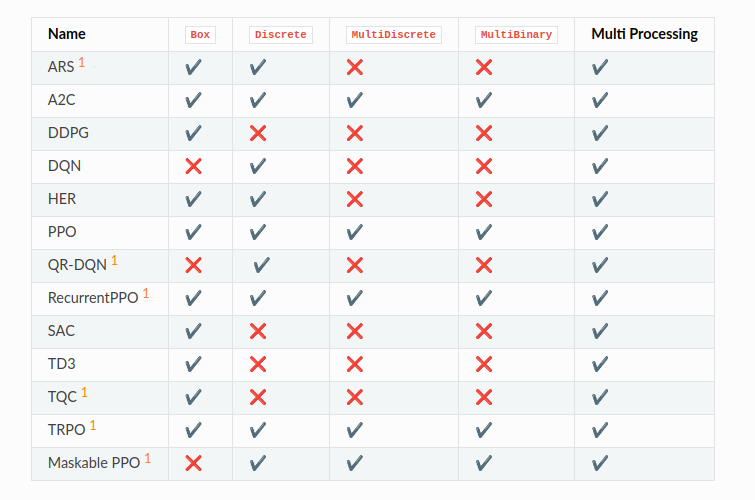

Copyright 2021-2024, Stable Baselines3. Revision 5623d98f.

## **Hyper Parameters**
* **gamma** is the discount factor. It determines the **importance of future rewards compared to immediate rewards**. A high $\gamma$ (close to $1$) means that future rewards are nearly as significant as immediate rewards, encouraging strategies that consider long-term benefits.
* **alpha** is the learning rate. It dictates **how much new information overrides old information**. A high $\alpha$ means that learning updates make significant changes to the existing knowledge base (weights, values, etc.), which can speed up learning but risk overshooting optimal solutions. A low $\alpha$ leads to slower learning, potentially more stable but at the risk of getting stuck if the learning rate is too low to escape local optima.

# **Training**

## **Training Metrics**
* Evaluation Metrics: evaluation metrics have to do with the episode length and the episode reward mean. The length is how long is our episode, so if you play a game think of it as one single game, when we are trying to balance our CartPole, it is the maximum number of steps we are allowed to take.
* Time Metrics: these include frames per seconds (how fast you are processing), iterations, how many times you have actually gone through, time_elapsed is how long has been running, and total_timesteps, how many time steps you have actually taken in an episode.
* Loss Metrics: among loss metrics we got entropy loss, policy loss, value loss
* Other Metrics: in the other metrics we have explained variance, meaning how much variance in your environment your agent is able to explain, the learning rate, how fast our policy is actually updating, and n_update, which is how many updates we have actually made.

In Colab, we'll be installing stable baselines without GPU acceleration. However, if you wish to leverage GPU acceleration during training, you can simply install the appropriate PyTorch version. For example, if you want to use GPU acceleration on your machine, you can visit [pytorch.org](https://pytorch.org/get-started/locally/). Let me walk you through the steps:

* Click on "Install" and scroll down to find installation steps.
* Choose the appropriate options:
  * Select your operating system (e.g., Linux, Windows, Mac).
  * Choose the installation method (e.g., pip).
  * Select Python as the programming language.
  * Choose the appropriate compute option.
Note: CUDA and cuDNN are only supported on Nvidia GPUs. If you want to leverage GPU acceleration, you must have an Nvidia GPU to use CUDA.

# **Testing and Evaluating**

First we define a log_path to save our tensorboard log. This path needs to exist, so you should create them in your drive or local folder.

In [ ]:
log_path = os.path.join('Training', 'Logs')

Now we need to instatiate our algorithm.

In [ ]:
env = gym.make(env_name)
model = PPO("MlpPolicy", Monitor(env), verbose=1, tensorboard_log=log_path)

We are using a Multi-Layer Perceptron (MLP) Policy, which means we are employing a standard neural network and not using LSTM or CNN layers. An agent's policy can be thought of as the rule that dictates how it operates within the environment. Stable Baselines 3 offers three policy types: MlpPolicy, CnnPolicy, and MultiInputPolicy.

The second argument for the model is the environment; in this case, we used a DummyVectorEnvironment. We set verbose=1 because we want to log the results for that particular model. Additionally, we specified our TensorBoard log path, so tensorboard_log contains the log path that we defined earlier.

To train our model, we can use the `learn` method and specify the number of timesteps for which we want our agent to train. The complexity of the environment can help determine the appropriate number of timesteps.

In [ ]:
model.learn(total_timesteps=20000)

* **Explained Variance**: Indicates how well the critic’s value function predicts the empirical returns observed during training. It measures how much of the variance in the observed returns is explained by the model’s value prediction. Higher values indicate that the critic provides a good estimate of expected future reward.
* **Policy Gradient Loss**: Reflects the magnitude of the policy update performed by the actor. It indicates how strongly the policy parameters are being adjusted. Small values suggest small, incremental policy updates, while larger magnitudes indicate bigger changes.
* **Value Loss**: Represents the mean squared error between the predicted state values and the empirical returns. It measures how accurately the critic approximates the expected return from a given state. Lower values generally indicate better value predictions.
* **Loss**: The total loss is the weighted combination of the policy gradient loss, value loss, and entropy loss. It serves as the objective optimized during training but is not directly interpretable on its own.

## **Save and Reload the Model**


In [ ]:
PPO_path = os.path.join('Training', 'Saved_Models', 'PPO_cartpole')

In [ ]:
model.save(PPO_path)

In [ ]:
del model

In [ ]:
model = PPO.load(PPO_path, env=env)

In [ ]:
model.learn(total_timesteps=1000)

## **Evaluation**
For the evaluation we are going to use the evaluate_policy method we imported before. In this specific case, the PPO is considered solved if you get an average score of 200 and higher.

In [ ]:
evaluate_policy(model, Monitor(env), n_eval_episodes=10, render=False)

This evaluation will run our policy for $10$ episodes, during which it will calculate the average reward and the standard deviation of rewards. In the CartPole environment, the reward is computed as 1 point for each timestep that the pole remains upright, with a maximum of $200$ steps per episode. An episode terminates early if the pole tilts more than $15$ degrees from vertical, or if the cart moves more than $2.4$ units from the center.

In [ ]:
env.close() #if you want to close the environment on jupyter notebook

## **Test the model**

Now that we have evaluated our policy, we can deploy it by reusing the code we wrote earlier. Instead of selecting actions at random, we will now pass the environment observations to our agent to predict the best action that maximizes our reward.

In [ ]:
env = gym.make(env_name, render_mode='rgb_array')
episodes = 5
for episode in range(1, episodes + 1):
    obs, info = env.reset()
    done = False
    score = 0

    while not done:
        env.render()

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        score += reward

    print(f"Episode {episode}, Score {score}")

env.close()

## **View Logs in Tensorboard**

In [ ]:
training_log_path = os.path.join(log_path, 'PPO_1') # switch the name of 'PPO_1' to the log name of your own trained model if necessary so that you are visualizing the correct tranining logs

In [ ]:
%load_ext tensorboard
%tensorboard --logdir={training_log_path}

When training your model, the core metric you should be looking at is your average reward. This provides an indication of how well your model will perform in a specific environment using a particular reward function. Another metric to consider is your average episode length. This metric aims to identify how long your agent lasts in a specific environment, which is especially important in environments that do not have a fixed episode length.

If your model is not performing well, consider three key strategies:

1. Train for a longer period.
2. Perform hyperparameter tuning; Stable Baselines supports parameter tuning using a package called Optuna.
3. Investigate the algorithms that are used for state-of-the-art training.

## **Callbacks, Alt Algorithms, Architectures**

A callback is a powerful tool that allows you to insert custom behavior into the training loop of an agent. These callbacks can be used to monitor the agent’s performance, apply early stopping, save the best model, modify the training environment, or even change the learning parameters during training.

In [ ]:
save_path = os.path.join('Training', 'Saved_Models')

In [ ]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=200, verbose=1)
eval_callback = EvalCallback(env, callback_on_new_best=stop_callback, eval_freq=10000, best_model_save_path=save_path, verbose=1)

In [ ]:
model = PPO('MlpPolicy', env, verbose=1, tensorboard_log=log_path)

In [ ]:
model.learn(total_timesteps=20000, callback=eval_callback)

# **Changing Policies**

In [ ]:
net_arch = dict(
    pi=[128, 128, 128, 128],
    vf=[128, 128, 128, 128]
)

In [ ]:
model = PPO('MlpPolicy', env, verbose=1, tensorboard_log=log_path, policy_kwargs={'net_arch': net_arch})

In [ ]:
model.learn(total_timesteps=20000, callback=eval_callback)

The documentation of Stable Baselines 3 provides a great guide to [Policy Networks](https://stable-baselines3.readthedocs.io/en/master/guide/custom_policy.html).

## **Alternative algorithm**

In [ ]:
model = DQN('MlpPolicy', env, verbose=1, tensorboard_log=log_path)

In [ ]:
model.learn(total_timesteps=20000)

# **Practicals**


1.   Use the RL algorithm of SAC to train a control policy for the task of [Pendulum-v1](https://gymnasium.farama.org/environments/classic_control/pendulum/) for 20k steps.
2.   During the training process, save the models with the name prefix of 'SAC_Pendulum' and evaluate the policy performance every 5k steps. Also use tensorboard to log your training process. You might find [this tutorial](https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html) be useful.
3.   Upload all your saved policy models and your tensorboard file.
4.   Repeat step 1-3 for the task of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car/), and use the name prefix of 'SAC_MountainCar' in step 2.
5. What did you find when comparing the results between the two tasks? Did the same RL algorithm well solve both tasks? What could be the reasons for these results?



In [ ]:
# create the gym environment for the task of Pendulum-v1, and specify the saving path for your tensorboard logs
'''
  Your code here
'''

# instatiate the SAC algorithm
'''
  Your code here
'''

# create a checkpoint saving callback to save policy models every 5k steps during the training process
'''
  Your code here
'''

# Start the training
'''
  Your code here
'''

# Close the environment
'''
  Your code here
'''

In [ ]:
# repeat for the task of MountainCar-v0
'''
  Your code here
'''

In [ ]:
# plot your result (tensorboard)
'''
  Your code here
'''

## Compare your result
---

# **References**
* [Spinning up OpenAI](https://spinningup.openai.com/en/latest/spinningup/rl_intro2.html#citations-below)
* The video tutorial "Reinforcement Learning in 3 Hours: Full Course in Python" from [Nicholas Renotte](https://www.youtube.com/watch?v=Mut_u40Sqz4&list=PL6iQBmDFQUfjxMcabYOCerMzuALpzYYiX&index=8)
